## CMPE-257, Machine Learning, Summer 2025
## Week 3: Linear Regression and Classification

In this workbook, you will be exporing some linear models:

- linear and multilinear regressions
- classification with logistic regression
- classification with naive Bayes

In [100]:
# YOUR NAME: Quoc Dung Lam

In [101]:
# loads required modules
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

## PART 1: Linear and Multilinear Regressions

In [102]:
# The following function is used to display some linear regression scores of interest for regression models 
# generated with the statsmodels module

def report_stats(rslt,pflag=True,rflag=False):
    tdx = {}
    lbls1 = ['coefficient','standard error','t-statistic','p-value']
    scrs1 = [rslt.params,rslt.bse,rslt.tvalues,rslt.pvalues]
    if pflag: display(pd.DataFrame(scrs1,index=lbls1).T)
    for k,v in zip(lbls1,scrs1): tdx[k]=v
    lbls2 = ['Residual SE','R-squared','Adjusted Rsq','F-statistic']
    scrs2 = [np.sqrt(rslt.ssr/(rslt.nobs-rslt.params.shape[0])),rslt.rsquared,rslt.rsquared_adj,rslt.fvalue]
    if pflag: display(pd.DataFrame(scrs2,index=lbls2,columns=['Model Scores']).T)
    for k,v in zip(lbls2,scrs2): tdx[k]=v
    if rflag: return tdx

In [103]:
# Exercise #1: consider the three-point regression exercise conducted in class, which is reproduced in this cell

# Creates a dataframe containing the three point in-sample dataset {p1:(1.0,4.50), p2:(2.0,2.5), p3:(3.0,2.0)}
# and adds a constant variable xo which will be associated to the constant term parameter (i.e. the intercept)
data = pd.DataFrame([[1,1,4.5],[1,2,2.5],[1,3,2]],columns=['xo','x1','y'])
#display(data)

# Performs the linear regression and prints the main scores and statistics
reg = sm.OLS(data['y'],data[['xo','x1']]).fit()
report_stats(reg)

,coefficient,standard error,t-statistic,p-value
xo,5.50,0.935414,5.879747,0.107247
x1,-1.25,0.433013,-2.886751,0.212296


,Residual SE,R-squared,Adjusted Rsq,F-statistic
Model Scores,0.612372,0.892857,0.785714,8.333333


In [104]:
# How results in exercises #1 compare to the results obtained in class?
# It has the same result.

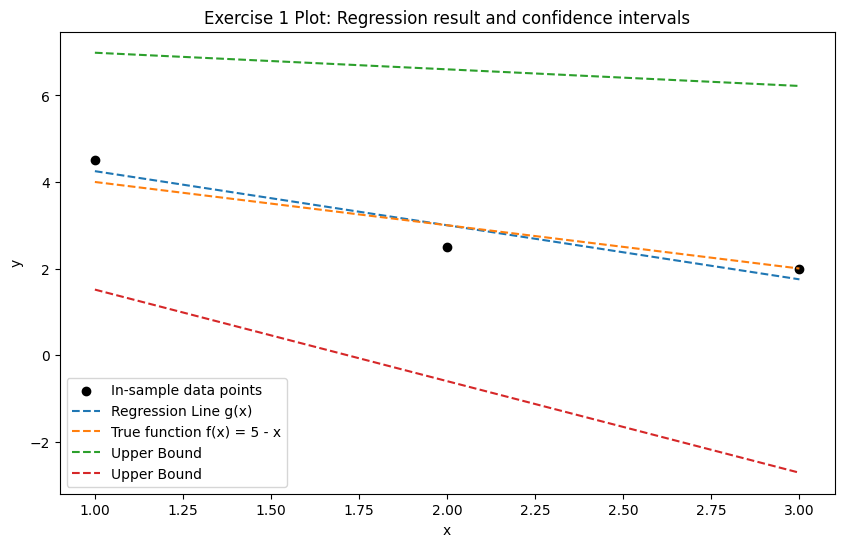

In [105]:
# Exercise #1 (continuation): generate a plot including the following elements: the three in-sample data points,
# the obtained regression line g(x), the actual generating function f(x) = 5 - x, and the two boundary lines that
# can be derived from the confidence intervals b+/-2SE(b) and m+/-2SE(m) 

# Extract x and y
x = data['x1']
y = data['y']

b = reg.params['xo']
m = reg.params['x1']

se_b = reg.bse['xo']
se_m = reg.bse['x1']

x_range = np.linspace(x.min(), x.max(), 100)

g_x = b + m * x_range

f_x = 5 - x_range

upper_bound = (b + 2*se_b) + (m + 2*se_m) * x_range
lower_bound = (b - 2*se_b) + (m - 2*se_m) * x_range

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='black', label='In-sample data points')
plt.plot(x_range, g_x, '--', label='Regression Line g(x)')
plt.plot(x_range, f_x, '--', label='True function f(x) = 5 - x')
plt.plot(x_range, upper_bound, '--', label='Upper Bound')
plt.plot(x_range, lower_bound, '--', label='Upper Bound')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Exercise 1 Plot: Regression result and confidence intervals')
plt.legend()
plt.show()


In [106]:
# How your generated plot compares to the one presented in class?
# It has the similar result.

In [107]:
# Exercise #2: download the file "Advertising.csv" from the book website, use the following link
# "https://www.statlearning.com/s/Advertising.csv". This dataset contains 200 data points comprising 
# three predictor varaibles (TV, radio, newspaper) and one target variable (sales).

# load the dataset... 
data = pd.read_csv('Advertising.csv')

# and add a constant variable (intercept)
data['intercept'] = [1.0 for x in range(data.shape[0])]

# compute a linear regression on the predictor variable TV and show the stats
reg_tv = sm.OLS(data['sales'],data[['intercept','TV']]).fit()
report_stats(reg_tv)

,coefficient,standard error,t-statistic,p-value
intercept,7.032594,0.457843,15.360275,1.406300e-35
TV,0.047537,0.002691,17.667626,1.467390e-42


,Residual SE,R-squared,Adjusted Rsq,F-statistic
Model Scores,3.258656,0.611875,0.609915,312.144994


In [108]:
# How these results compare to the ones in the book (Tables 3.1 and 3.2 in Section 3.1)?
# It has the similar result

In [109]:
# Exercise #2 (continuation): compute a linear regression on the predictor variable radio and show the stats

reg_radio = sm.OLS(data['sales'],data[['intercept','radio']]).fit()
report_stats(reg_radio)


,coefficient,standard error,t-statistic,p-value
intercept,9.311638,0.562900,16.542245,3.561071e-39
radio,0.202496,0.020411,9.920765,4.354966e-19


,Residual SE,R-squared,Adjusted Rsq,F-statistic
Model Scores,4.274944,0.332032,0.328659,98.421588


In [110]:
# How these results compare to the ones in the book (Table 3.3 in Section 3.1)?
# It has a same result

In [111]:
# Exercise #2 (continuation): compute a linear regression on the predictor variable newspaper and show the stats

reg_newspp = sm.OLS(data['sales'],data[['intercept','newspaper']]).fit()
report_stats(reg_newspp)


,coefficient,standard error,t-statistic,p-value
intercept,12.351407,0.621420,19.876096,4.713507e-49
newspaper,0.054693,0.016576,3.299591,1.148196e-03


,Residual SE,R-squared,Adjusted Rsq,F-statistic
Model Scores,5.09248,0.05212,0.047333,10.887299


In [112]:
# How these results compare to the ones in the book (Table 3.3 in Section 3.1)?
# It has a similar result

In [113]:
# Exercise #3: compute a mutilinear regression on the three predictor variables (TV, radio, and newspaper) 
# and show the resulting stats.

reg_multi = sm.OLS(data['sales'],data[['intercept', 'TV', 'radio', 'newspaper']]).fit()
report_stats(reg_multi)


,coefficient,standard error,t-statistic,p-value
intercept,2.938889,0.311908,9.422288,1.267295e-17
TV,0.045765,0.001395,32.808624,1.509960e-81
radio,0.188530,0.008611,21.893496,1.505339e-54
newspaper,-0.001037,0.005871,-0.176715,8.599151e-01


,Residual SE,R-squared,Adjusted Rsq,F-statistic
Model Scores,1.68551,0.897211,0.895637,570.270704


In [114]:
# How these results compare to the ones in the book (Table 3.4 in Section 3.2)? And how they compare to the
# single variable regressions from exercise #2? (make sure you include comments on R-squared and p-values)

# It has the same results to the ones in the book (Table 3.4 in Section 3.2)
# It has all different numbers compare to the single variable regression from ex2. The R-squared is much bigger, meaning it's fit the model using multiple regression more than
# single variable regression. Both Ex2 and Ex3 has low p-value, meaning the corresponding variable is statistically significant, rejecting the null hypothesis. 

In [115]:
# Exercise #3 (continuation): compute the corresponding correlation coefficients among the different pairs
# of predictor variables, and between the predictor and target variabls as well. 

# Compute correlation matrix
corr_matrix = data[['TV', 'radio', 'newspaper', 'sales']].corr()

# Display it
print(corr_matrix)


                 TV     radio  newspaper     sales
TV         1.000000  0.054809   0.056648  0.782224
radio      0.054809  1.000000   0.354104  0.576223
newspaper  0.056648  0.354104   1.000000  0.228299
sales      0.782224  0.576223   0.228299  1.000000


In [116]:
# How these results compare to the ones in the book (Table 3.5 in Section 3.2)? What these results are telling?

# It has similar result. Notice that the correlation between radio and newspaper is 0.35. This indicates
# that markets with high newspaper advertising tend to also have high radio advertising

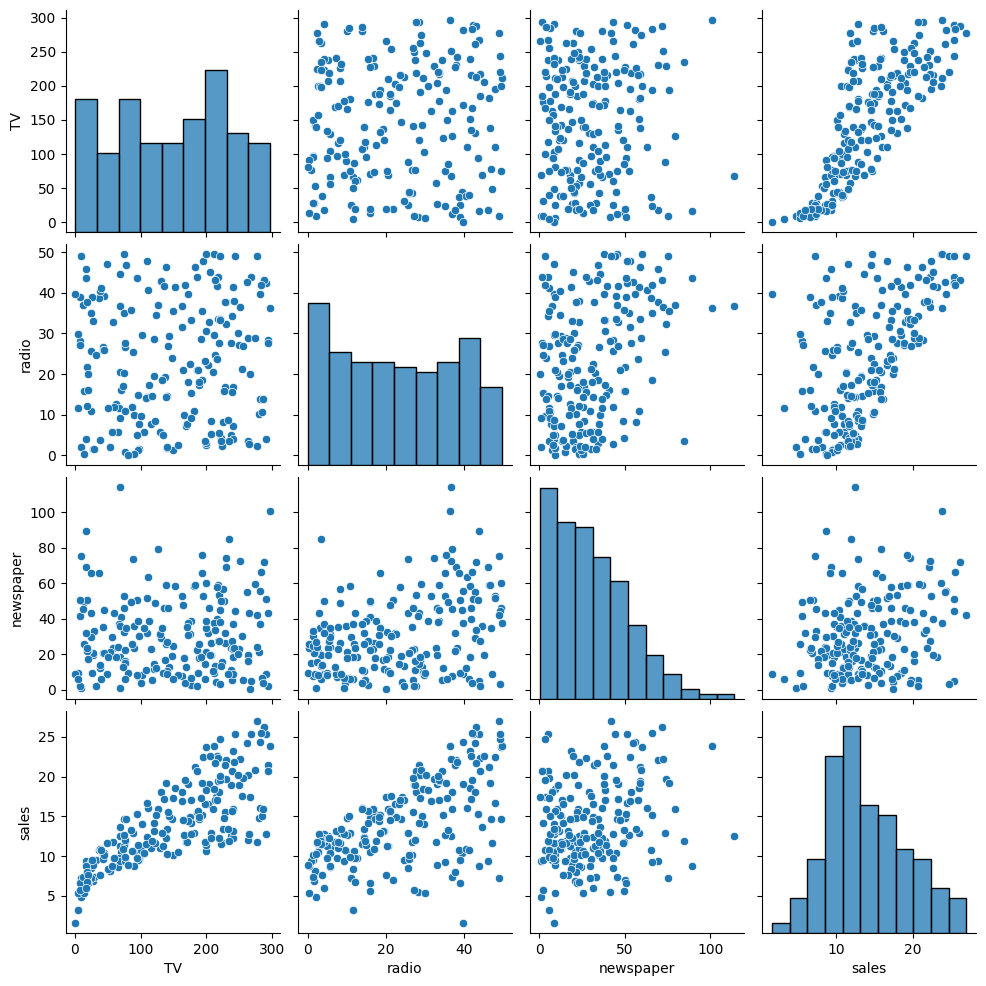

In [117]:
# Exercise #3 (continuation): use funtion pairplot in the seaborn library to generte the scatterplot matrix for
# the predictor variables (TV, radio, and newspaper) and target variable.

sns.pairplot(data[['TV', 'radio', 'newspaper', 'sales']])


In [118]:
# Any observations about your last results from exercises #3?

# TV and sales have a positive linear relationship
# Radio and sales have a moderate relationship
# Newspaper and sales have a weak relationship
# The relationship between predictors is insufficient

In [119]:
# Exercise #4: explore the interaction effect between the two predictor variebles TV and radio. First, create
# a new variable "TV x radio" by multiplying these two variables. Then, compute mutilinear regressions on the
# two variables and on the two variables plus the newly created one. Print the corresponding stat reports.

data['TVxradio'] = data['TV'] * data['radio']
reg_TV_radio = sm.OLS(data['sales'],data[['intercept', 'TV', 'radio']]).fit()
report_stats(reg_TV_radio)

reg_multi_TVxradio = sm.OLS(data['sales'],data[['intercept', 'TV', 'radio', 'TVxradio']]).fit()
report_stats(reg_multi_TVxradio)

,coefficient,standard error,t-statistic,p-value
intercept,2.921100,0.29449,9.919193,4.565557e-19
TV,0.045755,0.00139,32.908708,5.436980e-82
radio,0.187994,0.00804,23.382446,9.776972e-59


,Residual SE,R-squared,Adjusted Rsq,F-statistic
Model Scores,1.681361,0.897194,0.896151,859.617718


,coefficient,standard error,t-statistic,p-value
intercept,6.750220,0.247871,27.232755,1.541461e-68
TV,0.019101,0.001504,12.698953,2.363605e-27
radio,0.028860,0.008905,3.240815,1.400461e-03
TVxradio,0.001086,0.000052,20.726564,2.757681e-51


,Residual SE,R-squared,Adjusted Rsq,F-statistic
Model Scores,0.943515,0.967791,0.967298,1963.056876


In [120]:
# How these results compare to the ones in the book (Table 3.9 in Section 3.3)? What can be said about the
# interaction effect between the two predictor variables TV and Radio?
# It has the same result. The two predictor variables TV and Radio is a superior model. P-value is low, suggesting statistically significant.
# R-Squared's 96.8%,  higher than 89.7%. If we include an interaction in a model, we should also include the main effect.

In [121]:
# Exercise #5: explore a potential non-linear relationships between the predictor variable TV and the target 
# variable sales. Suggestion: consider a reationship of the type Y ~ log(X)

print("Reg_TV Stats")
reg_tv = sm.OLS(data['sales'], data[['intercept','TV']]).fit()
report_stats(reg_tv)


Reg_TV Stats


,coefficient,standard error,t-statistic,p-value
intercept,7.032594,0.457843,15.360275,1.406300e-35
TV,0.047537,0.002691,17.667626,1.467390e-42


,Residual SE,R-squared,Adjusted Rsq,F-statistic
Model Scores,3.258656,0.611875,0.609915,312.144994


In [122]:
print("Reg_Log_TV Stats")
data['log_TV'] = np.log(data['TV'])
reg_log_tv= sm.OLS(data['sales'], data[['intercept','log_TV']]).fit()
report_stats(reg_log_tv)

Reg_Log_TV Stats


,coefficient,standard error,t-statistic,p-value
intercept,-4.202588,1.162253,-3.615898,3.797320e-04
log_TV,3.900875,0.243227,16.038021,1.206373e-37


,Residual SE,R-squared,Adjusted Rsq,F-statistic
Model Scores,3.449655,0.565044,0.562847,257.218118


In [123]:
# What are your main conclusions from resulst in exercise #5?

# Reg_TV Model is better fit overall. It has higher R-squared and lower RSE.  

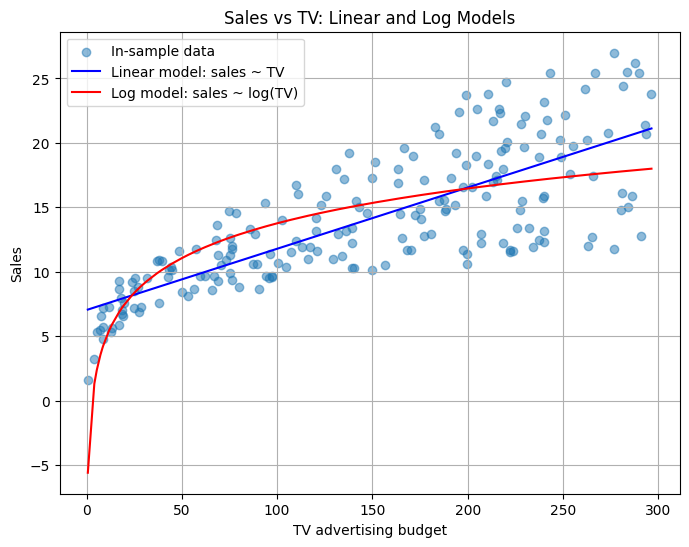

In [124]:
# Exercise #5 (continuation): generate plot displaying the in-sample data and the two regression
# models obtained in the previous step of exercise #5.

# Create a smooth range of TV values
tv_sorted = sorted(data['TV'])
log_tv_sorted = np.log(tv_sorted)

# Build prediction DataFrames
X_linear = pd.DataFrame({'intercept': 1, 'TV': tv_sorted})
X_log = pd.DataFrame({'intercept': 1, 'log_TV': log_tv_sorted})

# Predict values
linear_pred = reg_tv.predict(X_linear)
log_pred = reg_log_tv.predict(X_log)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(data['TV'], data['sales'], alpha=0.5, label='In-sample data')
plt.plot(tv_sorted, linear_pred, label='Linear model: sales ~ TV', color='blue')
plt.plot(tv_sorted, log_pred, label='Log model: sales ~ log(TV)', color='red')
plt.xlabel('TV advertising budget')
plt.ylabel('Sales')
plt.title('Sales vs TV: Linear and Log Models')
plt.legend()
plt.grid(True)
plt.show()


In [125]:
# What are your main observations?
# The Log_TV Model underestimates the sales when using high TV Budget, fits low and medium portion of the data.
# The TV_Model fits the middle nicely, overestimate at the low TV budget but underestimate high budget.

## PART 2: Classification with Logistic Regression

In [126]:
# loads required modules
from tqdm import tqdm
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report

In [127]:
# Exercise #6: this cell includes python code to load a text dataset and train a logistic regression model 
# on it. Inspect the different steps in the script and run the code

# Step 1: loads the experiemtal data collection "Books.csv"
books = pd.read_csv('Books.csv')
#display(books)
# This dataset contains selected paragraphs from three different books:
# Pride and Prejudice by Jane Austen [eBook #1342 @ https://www.gutenberg.org/]
# Moby Dick; Or, The Whale by Herman Melville [eBook #2701 @ https://www.gutenberg.org/]
# Oliver Twist by Charles Dickens [eBook #730 @ https://www.gutenberg.org/]
# Three fields are provided: doc_id (composed of three parts: book id, chapter id and paragraph id), raw_text
# (the original paragraph contents) and tokenized_text (a tokenized version with punctuation marks removed) 

# Step 2: adds an additional column conatining the book id only
books['targets'] = [x.split('-')[0] for x in books['doc_id']]
labels = sorted(books['targets'].drop_duplicates().values)

# Step 3: splits the data into in-sample (train) and out-of-sample (test) datasets, using 50% of the data for each
train,test = train_test_split(books[['tokenized_text','targets']],test_size=0.5)

# Step 4: uses the in-sample (train) data to train the vectorizer, which uses word counts as features to represent 
# each paragraph in the dataset. Retains the 200 words with highest counts to be used as predictor variables.
trn_text = train['tokenized_text'].values
vectorizer = CountVectorizer(max_features = 200)
trn_feat = vectorizer.fit_transform(trn_text)

# Step 5: computes the corresponding feature vectors for the out-of-sample (test) portion of the data.
tst_text = test['tokenized_text'].values
tst_feat = vectorizer.transform(tst_text)

# Step 6: gets the target vectors for each portion of the dataset: in-sample and out-of-sample
trn_trgt = train['targets'].values
tst_trgt = test['targets'].values

# Step 7: trains a multilinear regression model
logreg = linear_model.LogisticRegression()
logreg.fit(trn_feat, trn_trgt)

# Step 8: applies the model to the in-sample dataset and computes confusion matrix and evauation scores
trn_pdct = logreg.predict(trn_feat)
print('\nIn-sample data evaluation scores:\n')
scores_trn_lreg = classification_report(trn_trgt,trn_pdct)
print(scores_trn_lreg)

ex6_in_f1 = 1.0 - classification_report(trn_trgt,trn_pdct,output_dict=True)['weighted avg']['f1-score']

# Step 9: applies the model to the out-of-sample dataset and computes confusion matrix and evauation scores
tst_pdct = logreg.predict(tst_feat)
print('\nOut-of-sample data evaluation scores:\n')
scores_tst_lreg = classification_report(tst_trgt,tst_pdct)
print(scores_tst_lreg)
ex6_out_f1 = 1.0 - classification_report(tst_trgt,tst_pdct,output_dict=True)['weighted avg']['f1-score']


In-sample data evaluation scores:

              precision    recall  f1-score   support

         000       0.94      0.94      0.94       624
         001       0.93      0.91      0.92       663
         002       0.93      0.95      0.94      1096

    accuracy                           0.93      2383
   macro avg       0.94      0.93      0.93      2383
weighted avg       0.93      0.93      0.93      2383


Out-of-sample data evaluation scores:

              precision    recall  f1-score   support

         000       0.90      0.87      0.88       618
         001       0.86      0.85      0.85       627
         002       0.88      0.90      0.89      1138

    accuracy                           0.88      2383
   macro avg       0.88      0.87      0.87      2383
weighted avg       0.88      0.88      0.88      2383



In [128]:
# What are your main conclusions from the results obtained in exercise #6?
# Out-of-sample test is lower than in-sample but only 7% different.
# The accuracy drops from 94% to 87%.
# The model demonstrates strong predictability, no major signs of overfitting.

C:\Users\Danny Lam\AppData\Local\Temp\ipykernel_11680\2619143000.py:14: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(in_predict_proba[:, 0], in_predict_proba[:, 1], in_predict_proba[:, 2], c=color_labels, cmap='viridis', alpha=0.6)


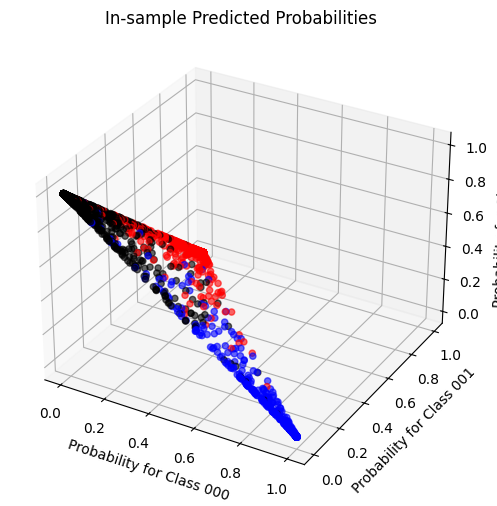

C:\Users\Danny Lam\AppData\Local\Temp\ipykernel_11680\2619143000.py:23: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(out_predict_proba[:, 0], out_predict_proba[:, 1], out_predict_proba[:, 2], c=color_labels, cmap='viridis', alpha=0.6)


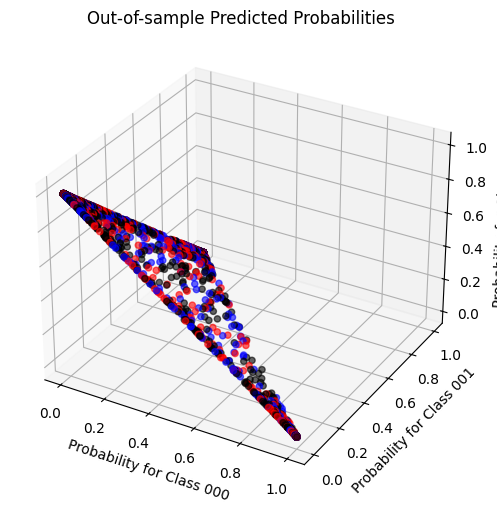

In [129]:
# Exercise #7: compute the associted predicted probabilities for each data point in both in-sample (train)
# and out-of-sample (test) datasets (use the "predict_proba" method for obtaining prediciton probabilities).
# Generate two three-dimensional scatter plots (one for each dataset) showing the predicted probabilities
# for each data point and color each data point according to its actual category: 000, 001, or 002.

in_predict_proba = logreg.predict_proba(trn_feat)
out_predict_proba = logreg.predict_proba(tst_feat)

color_map = {'000': 'blue', '001': 'red', '002': 'black'}
color_labels = [color_map[label] for label in trn_trgt]

fig = plt.figure(figsize=(8,6))
ax=fig.add_subplot(111, projection='3d')
ax.scatter(in_predict_proba[:, 0], in_predict_proba[:, 1], in_predict_proba[:, 2], c=color_labels, cmap='viridis', alpha=0.6)
ax.set_xlabel('Probability for Class 000')
ax.set_ylabel('Probability for Class 001')
ax.set_zlabel('Probability for Class 002')
ax.set_title('In-sample Predicted Probabilities')
plt.show()

fig = plt.figure(figsize=(8, 6))
ax=fig.add_subplot(111, projection='3d')
ax.scatter(out_predict_proba[:, 0], out_predict_proba[:, 1], out_predict_proba[:, 2], c=color_labels, cmap='viridis', alpha=0.6)
ax.set_xlabel('Probability for Class 000')
ax.set_ylabel('Probability for Class 001')
ax.set_zlabel('Probability for Class 002')
ax.set_title('Out-of-sample Predicted Probabilities')
plt.show()


In [130]:
# What are your main observations from the genereated scatter plots? How are the points distributed in the
# three-dimensional probability space? Can you explain why?
# For in-sample data, most data points are clustered into the corner. The model is confident and can classify very well. The model fits tightly.
# For out-sample data, points are spread out, indicating its weak confidence.

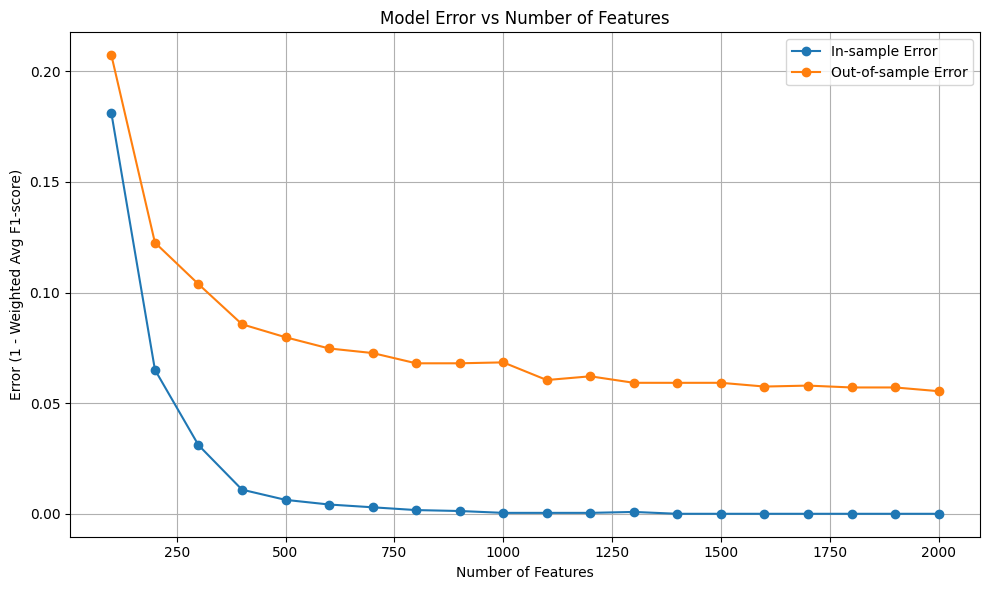

In [131]:
# Exercise #8: create a script to iterate over the number of features from 100 to 2000 (in 100 increments) and 
# generate a plot displaying both the in-sample and out-of-sample errors versus the number of features. Use the 
# "max_features" parameter of "CountVectorizer" to indicate the number of features at each iteration. Consider 
# as error values: 1.0 - weigthwe_avg_F1-score.

# Initialize results
feature_counts = list(range(100, 2001, 100))
in_errors = []
out_errors = []

# Loop over different feature counts
for n in feature_counts:
    vectorizer = CountVectorizer(max_features=n)
    trn_feat = vectorizer.fit_transform(trn_text)
    tst_feat = vectorizer.transform(tst_text)

    model = linear_model.LogisticRegression(max_iter=1000)
    model.fit(trn_feat, trn_trgt)

    # Predict and get classification reports
    trn_pred = model.predict(trn_feat)
    tst_pred = model.predict(tst_feat)

    trn_report = classification_report(trn_trgt, trn_pred, output_dict=True)
    tst_report = classification_report(tst_trgt, tst_pred, output_dict=True)

    # Compute 1 - weighted avg F1-score
    in_error = 1.0 - trn_report['weighted avg']['f1-score']
    out_error = 1.0 - tst_report['weighted avg']['f1-score']

    in_errors.append(in_error)
    out_errors.append(out_error)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(feature_counts, in_errors, label='In-sample Error', marker='o')
plt.plot(feature_counts, out_errors, label='Out-of-sample Error', marker='o')
plt.xlabel('Number of Features')
plt.ylabel('Error (1 - Weighted Avg F1-score)')
plt.title('Model Error vs Number of Features')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [132]:
# What are your main observations from exercise #8? Do the error curves behave as you were expecting? 
# Can you provide an explanation for the observed result?
# As expected, non-linear regression fits the in-sample data with a very low error. With 750+ features, the model flat out
# For test data, the model has a dimished return after 500+ feaures. While it's improving, there's an unavoidable error.
# From 100-700 features, the model captures meaningful pattern. While the model fit the training data with 700-1000 features, it gains little on test data 

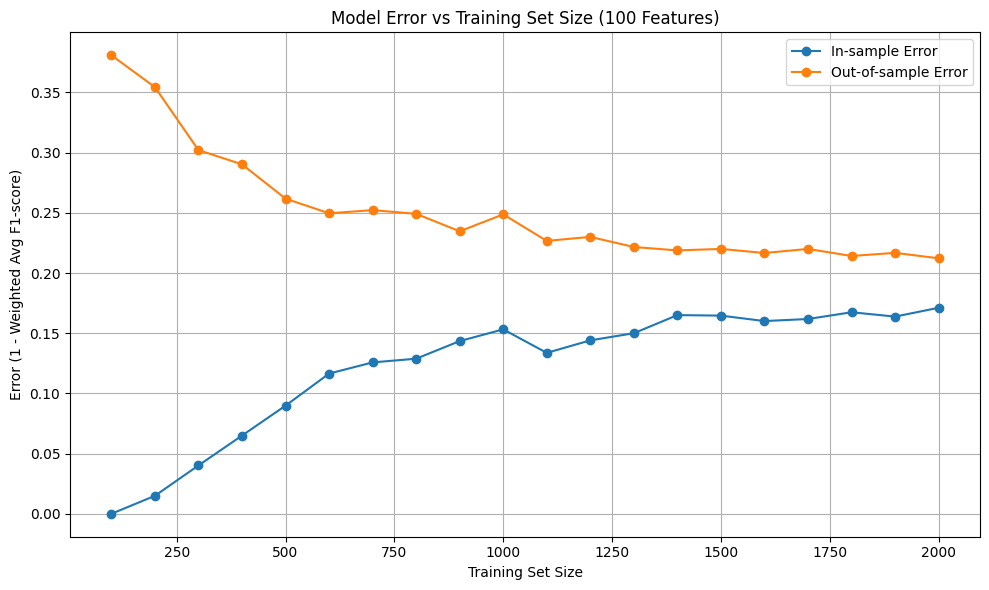

In [133]:
# Exercise #9: create a script to iterate over the in-sample (train) dataset size from 100 to 2000 (in 100 
# increments) while keeping the out-of-sample dataset fixed and generate a plot displaying both the in-sample 
# and out-of-sample errors versus the train data size. Set the "max_features" parameter of "CountVectorizer"
# to 100 for all iterations and, again, consider as error values: 1.0 - weigthwe_avg_F1-score.

train_sizes = list(range(100, 2001, 100))
in_errors = []
out_errors = []

for size in train_sizes:
    train_n = train[:size]
    trn_text = train_n['tokenized_text'].values
    trn_trgt = train_n['targets'].values

    # Vectorize with fixed 100 features
    vectorizer = CountVectorizer(max_features=100)
    trn_feat = vectorizer.fit_transform(trn_text)
    tst_feat = vectorizer.transform(tst_text)

    # Train and predict
    model = linear_model.LogisticRegression(max_iter=1000)
    model.fit(trn_feat, trn_trgt)
    
    trn_pred = model.predict(trn_feat)
    tst_pred = model.predict(tst_feat)

    trn_report = classification_report(trn_trgt, trn_pred, output_dict=True)
    tst_report = classification_report(tst_trgt, tst_pred, output_dict=True)

    in_error = 1.0 - trn_report['weighted avg']['f1-score']
    out_error = 1.0 - tst_report['weighted avg']['f1-score']

    in_errors.append(in_error)
    out_errors.append(out_error)

# Step 5: Plotting
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, in_errors, label='In-sample Error', marker='o')
plt.plot(train_sizes, out_errors, label='Out-of-sample Error', marker='o')
plt.xlabel('Training Set Size')
plt.ylabel('Error (1 - Weighted Avg F1-score)')
plt.title('Model Error vs Training Set Size (100 Features)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [134]:
# What are your main observations from exercise #9? Do the error curves behave as you were expecting? 
# Can you provide an explanation for the observed result?
# As more training data size, the model has a higher in-sample error and lower out-sample error. This behaves as I was expecting. 
# With more data, the model can't memorize them, so the in-sample error rise slightly.
# On the other hands, with less data, the model can only learn a little. The model improves in generalization with more data, but still, can't beat the in-sample error.

## PART 3: Classification with Naive Bayes

In [135]:
# loading required models
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import GaussianNB

In [136]:
# Exercise #10: consider a naive Bayes classifier (assuming multinomial distributions) for the three-book
# dataset from PART 2. Use the same in-sample/out-of-sampe data partition used before, train the classifier,
# apply the model to both data partitions and compute the corresponding evauation metrics. Note: you need
# to recompute the train and test features (which were modified in the previous exercise) by using the full 
# in-sample (train) dataset. Use "max_features = 200" in "CountVectorizer" so your resuts here are comparable
# to those from exercise #6.

books = pd.read_csv('Books.csv')
books['targets'] = [x.split('-')[0] for x in books['doc_id']]

train, test = train_test_split(books[['tokenized_text', 'targets']], test_size=0.5, random_state=42)

trn_text = train['tokenized_text'].values
tst_text = test['tokenized_text'].values
trn_trgt = train['targets'].values
tst_trgt = test['targets'].values

vectorizer = CountVectorizer(max_features=200)
trn_feat = vectorizer.fit_transform(trn_text)
tst_feat = vectorizer.transform(tst_text)

# Train the Multinomial Naive Bayes classifier
nb_model = MultinomialNB()
nb_model.fit(trn_feat, trn_trgt)

# In-sample
trn_pred = nb_model.predict(trn_feat)
print("In-sample Evaluation:\n")
print(classification_report(trn_trgt, trn_pred))
trn_report = classification_report(trn_trgt, trn_pred, output_dict=True)
MNB_in_error = 1.0 - trn_report['weighted avg']['f1-score']

# Out-of-sample
tst_pred = nb_model.predict(tst_feat)
print("Out-of-sample Evaluation:\n")
print(classification_report(trn_trgt, tst_pred))
tst_report = classification_report(tst_trgt, tst_pred, output_dict=True)
MNB_out_error = 1.0 - tst_report['weighted avg']['f1-score']



In-sample Evaluation:

              precision    recall  f1-score   support

         000       0.84      0.93      0.88       607
         001       0.88      0.85      0.86       659
         002       0.90      0.86      0.88      1117

    accuracy                           0.87      2383
   macro avg       0.87      0.88      0.87      2383
weighted avg       0.88      0.87      0.87      2383

Out-of-sample Evaluation:

              precision    recall  f1-score   support

         000       0.25      0.28      0.26       607
         001       0.30      0.27      0.28       659
         002       0.47      0.47      0.47      1117

    accuracy                           0.36      2383
   macro avg       0.34      0.34      0.34      2383
weighted avg       0.37      0.36      0.37      2383



In [137]:
# How your results from exercise #10 compare to those from exercise #6? What are your main conclusions?
# Logistic Regression slightly out-performs Naive Bayes for in-sample data.
# For out-sample data, Naive Bayes comes close to the precision of LR by having 86% accuracy compared to 87% of LR.

In [138]:
# Exercise #11: repeat exercise #10 but, in this case, assuming Bernoulli distributions

books = pd.read_csv('Books.csv')
books['targets'] = [x.split('-')[0] for x in books['doc_id']]

train, test = train_test_split(books[['tokenized_text', 'targets']], test_size=0.5, random_state=42)

trn_text = train['tokenized_text'].values
tst_text = test['tokenized_text'].values
trn_trgt = train['targets'].values
tst_trgt = test['targets'].values

vectorizer = CountVectorizer(max_features=200)
trn_feat = vectorizer.fit_transform(trn_text)
tst_feat = vectorizer.transform(tst_text)

# Train the BernoulliNB 
bn_model = BernoulliNB()
bn_model.fit(trn_feat, trn_trgt)

# In-sample
trn_pred = bn_model.predict(trn_feat)
print("In-sample BernoulliNB Evaluation:\n")
print(classification_report(trn_trgt, trn_pred))
trn_report = classification_report(trn_trgt, trn_pred, output_dict=True)
BNB_in_error = 1.0 - trn_report['weighted avg']['f1-score']

# Out-of-sample
tst_pred = bn_model.predict(tst_feat)
print("Out-of-sample BernoulliNB Evaluation:\n")
print(classification_report(tst_trgt, tst_pred))
tst_report = classification_report(trn_trgt, trn_pred, output_dict=True)
BNB_out_error = 1.0 - tst_report['weighted avg']['f1-score']


In-sample BernoulliNB Evaluation:

              precision    recall  f1-score   support

         000       0.88      0.88      0.88       607
         001       0.89      0.83      0.86       659
         002       0.86      0.89      0.87      1117

    accuracy                           0.87      2383
   macro avg       0.87      0.86      0.87      2383
weighted avg       0.87      0.87      0.87      2383

Out-of-sample BernoulliNB Evaluation:

              precision    recall  f1-score   support

         000       0.87      0.85      0.86       635
         001       0.87      0.82      0.84       631
         002       0.85      0.89      0.87      1117

    accuracy                           0.86      2383
   macro avg       0.86      0.85      0.86      2383
weighted avg       0.86      0.86      0.86      2383



In [139]:
# How your results from exercise #11 compare to those from exercise #10? What are your main conclusions?

# They have a similar result with only 1% off accuracy. 

In [140]:
# Exercise #12: repeat exercise #11 but, in this case, assuming Gaussian distributions. Note: in this case
# you might need to convert the features from sparse to dense representations 

books = pd.read_csv('Books.csv')
books['targets'] = [x.split('-')[0] for x in books['doc_id']]

train, test = train_test_split(books[['tokenized_text', 'targets']], test_size=0.5, random_state=42)

trn_text = train['tokenized_text'].values
tst_text = test['tokenized_text'].values
trn_trgt = train['targets'].values
tst_trgt = test['targets'].values

vectorizer = CountVectorizer(max_features=200)
trn_feat = vectorizer.fit_transform(trn_text).toarray()
tst_feat = vectorizer.transform(tst_text).toarray()

# Train the GaussianNB Naive Bayes classifier
gn_model = GaussianNB()
gn_model.fit(trn_feat, trn_trgt)

# In-sample
trn_pred = gn_model.predict(trn_feat)
print("In-sample GaussianNB Evaluation:\n")
print(classification_report(trn_trgt, trn_pred))
trn_report = classification_report(trn_trgt, trn_pred, output_dict=True)
GNB_in_error = 1.0 - trn_report['weighted avg']['f1-score']

# Out-of-sample
tst_pred = gn_model.predict(tst_feat)
print("Out-of-sample GaussianNB Evaluation:\n")
print(classification_report(tst_trgt, tst_pred))
tst_report = classification_report(trn_trgt, trn_pred, output_dict=True)
GNB_out_error = 1.0 - tst_report['weighted avg']['f1-score']


In-sample GaussianNB Evaluation:

              precision    recall  f1-score   support

         000       0.73      0.94      0.82       607
         001       0.72      0.96      0.82       659
         002       0.99      0.64      0.78      1117

    accuracy                           0.81      2383
   macro avg       0.81      0.85      0.81      2383
weighted avg       0.85      0.81      0.80      2383

Out-of-sample GaussianNB Evaluation:

              precision    recall  f1-score   support

         000       0.73      0.92      0.81       635
         001       0.71      0.93      0.81       631
         002       0.98      0.67      0.80      1117

    accuracy                           0.80      2383
   macro avg       0.81      0.84      0.81      2383
weighted avg       0.84      0.80      0.80      2383



In [141]:
# How your results from exercise #12 compare to those from exercises #11 and #10? What are your main conclusions?

# The Accuracy drops for both in and out-sample data, with 82% and 80% respectively.
# High recall of class 002, the model confuses

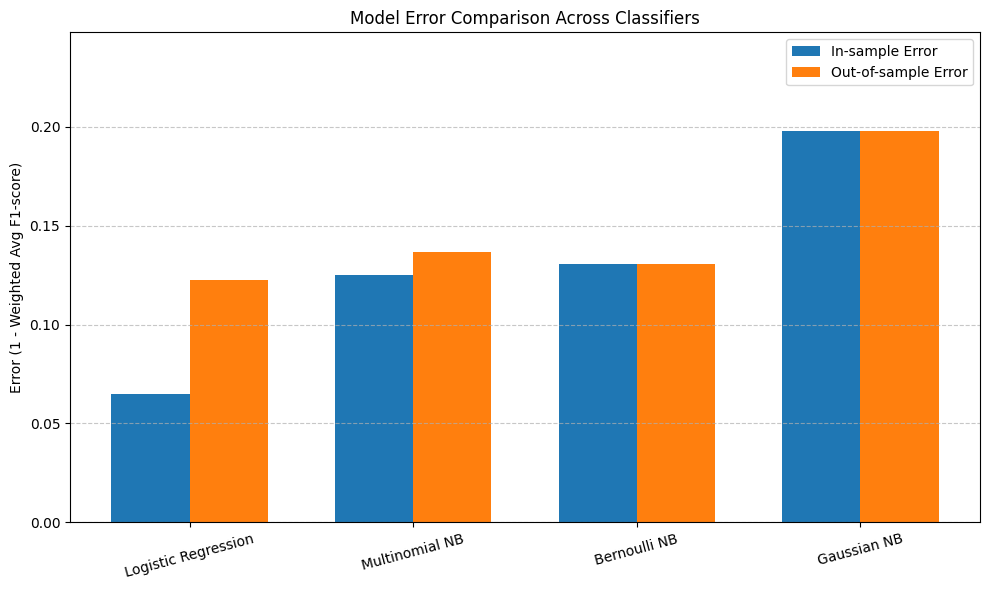

In [142]:
# Exercise #13: generate barplots comparing the weigthed average F1-scores for both in-sample (train) and
# out-of-sample (test) datasets among all different classifiers logistic regression (exercise #6), multinomial
# naive Bayes (exercise #10), Bernoulli naive Bayes (exercise #11), Gaussian naive Bayes (exercise #12)

# MNB_in_error
# MNB_out_error
# BNB_in_error
# BNB_out_error
# GNB_in_error
# GNB_out_error

# Classifier labels
classifiers = ['Logistic Regression', 'Multinomial NB', 'Bernoulli NB', 'Gaussian NB']

# In-sample and Out-of-sample errors (1 - weighted avg F1-score)
in_sample_errors = [
    ex6_in_f1,
    MNB_in_error,
    BNB_in_error,
    GNB_in_error
]

out_sample_errors = [
    ex6_out_f1,
    MNB_out_error,
    BNB_out_error,
    GNB_out_error
]

# Bar width and positions
x = np.arange(len(classifiers))
width = 0.35

# Plot
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, in_sample_errors, width, label='In-sample Error')
plt.bar(x + width/2, out_sample_errors, width, label='Out-of-sample Error')

# Labels and formatting
plt.ylabel('Error (1 - Weighted Avg F1-score)')
plt.title('Model Error Comparison Across Classifiers')
plt.xticks(x, classifiers, rotation=15)
plt.ylim(0, max(in_sample_errors + out_sample_errors) + 0.05)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
# What are your main conclusions?
# Logistic Regression gains best result, lowest in-sample and out-of-sample error among all models.
# Multinomial NB and Bernoulli NB perform similarly, with the slightly edge toward BNB
# Gaussian NB Performs Worst
# Logistic Regression is the most suitable method for this data set.


## PART 4: Term Project Proposal Title Submission

In [ ]:
# Please work with your team members to decide on a title for your term project, provide the agreed title and 
# the final list of team members in your team below. Important note: every student must complete this section!

# Your project tite: Vegetable Identifier

# Your team's members: 
# Quoc Dung Lam
# Ianna Duran
# Trevor O’Neil